<a href="https://colab.research.google.com/github/maitri100907/IBM-Data-Visualization-Final-Project/blob/main/IBM_Data_Visualization_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium

# Download and load the dataset
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/historical_automobile_sales.csv"
df = pd.read_csv(URL)

# Display the first 5 rows
df.head()

,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
0,1/31/1980,1980,Jan,1,108.24,0.50,27483.571,1558,7,60.223,0.010000,5.4,456.0,Supperminicar,Georgia
1,2/29/1980,1980,Feb,1,98.75,0.75,24308.678,3048,4,45.986,-0.309594,4.8,555.9,Supperminicar,New York
2,3/31/1980,1980,Mar,1,107.48,0.20,28238.443,3137,3,35.141,-0.308614,3.4,620.0,Mediumfamilycar,New York
3,4/30/1980,1980,Apr,1,115.01,1.00,32615.149,1653,7,45.673,0.230596,4.2,702.8,Supperminicar,Illinois
4,5/31/1980,1980,May,1,98.72,0.20,23829.233,1319,4,52.997,0.138197,5.3,770.4,Smallfamiliycar,California


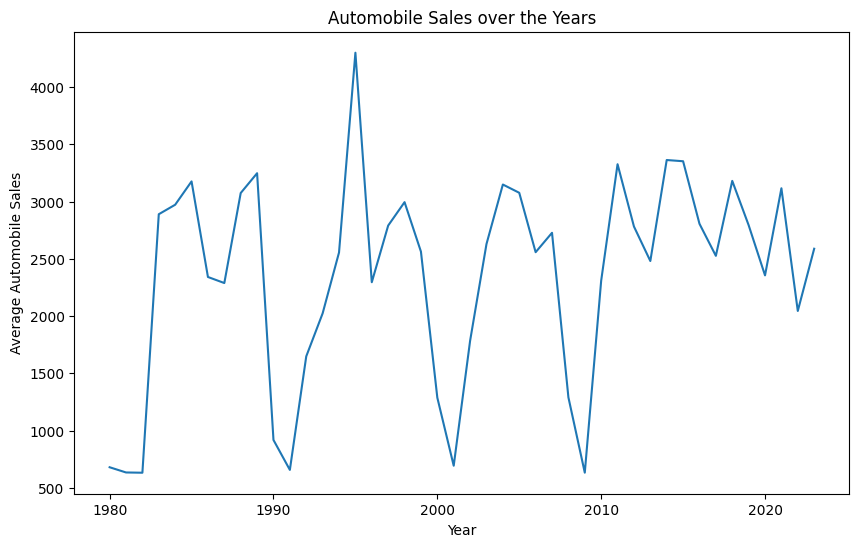

In [2]:
plt.figure(figsize=(10, 6))
df_line = df.groupby('Year')['Automobile_Sales'].mean()
df_line.plot(kind='line')
plt.title('Automobile Sales over the Years')
plt.xlabel('Year')
plt.ylabel('Average Automobile Sales')
plt.show()

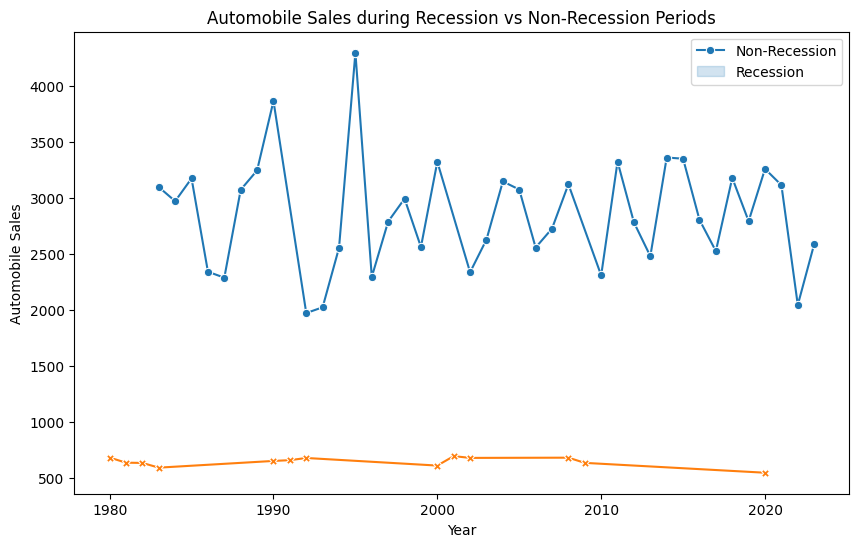

In [3]:
plt.figure(figsize=(10, 6))
df_recession = df.groupby(['Year', 'Recession'])['Automobile_Sales'].mean().reset_index()
sns.lineplot(data=df_recession, x='Year', y='Automobile_Sales', hue='Recession', style='Recession', markers=True, dashes=False)
plt.title('Automobile Sales during Recession vs Non-Recession Periods')
plt.xlabel('Year')
plt.ylabel('Automobile Sales')
plt.legend(['Non-Recession', 'Recession'])
plt.show()

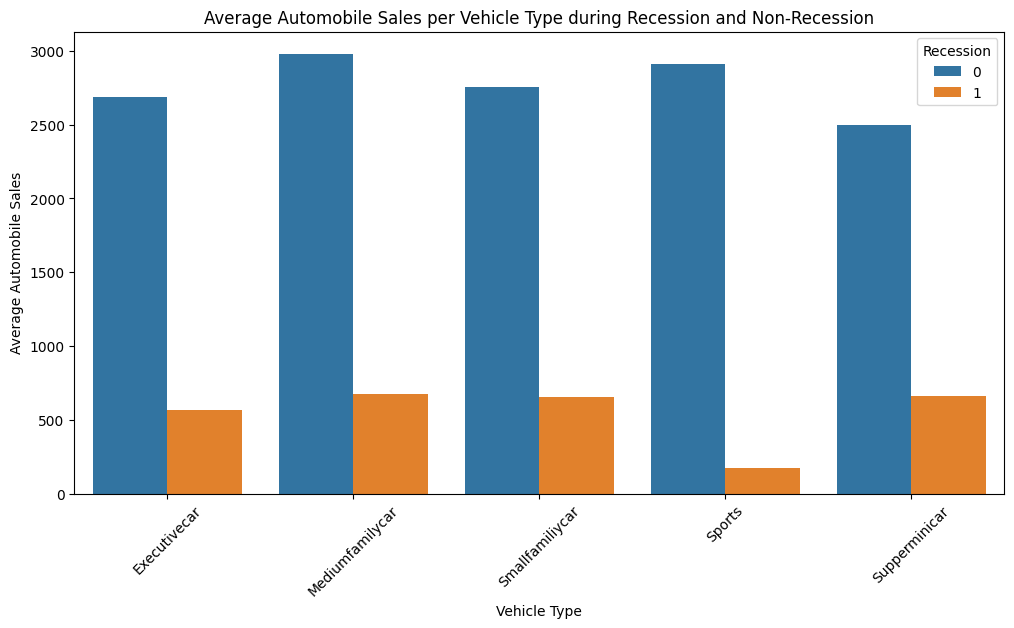

In [4]:
df_rec_type = df.groupby(['Recession', 'Vehicle_Type'])['Automobile_Sales'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=df_rec_type, x='Vehicle_Type', y='Automobile_Sales', hue='Recession')
plt.title('Average Automobile Sales per Vehicle Type during Recession and Non-Recession')
plt.xlabel('Vehicle Type')
plt.ylabel('Average Automobile Sales')
plt.xticks(rotation=45)
plt.show()

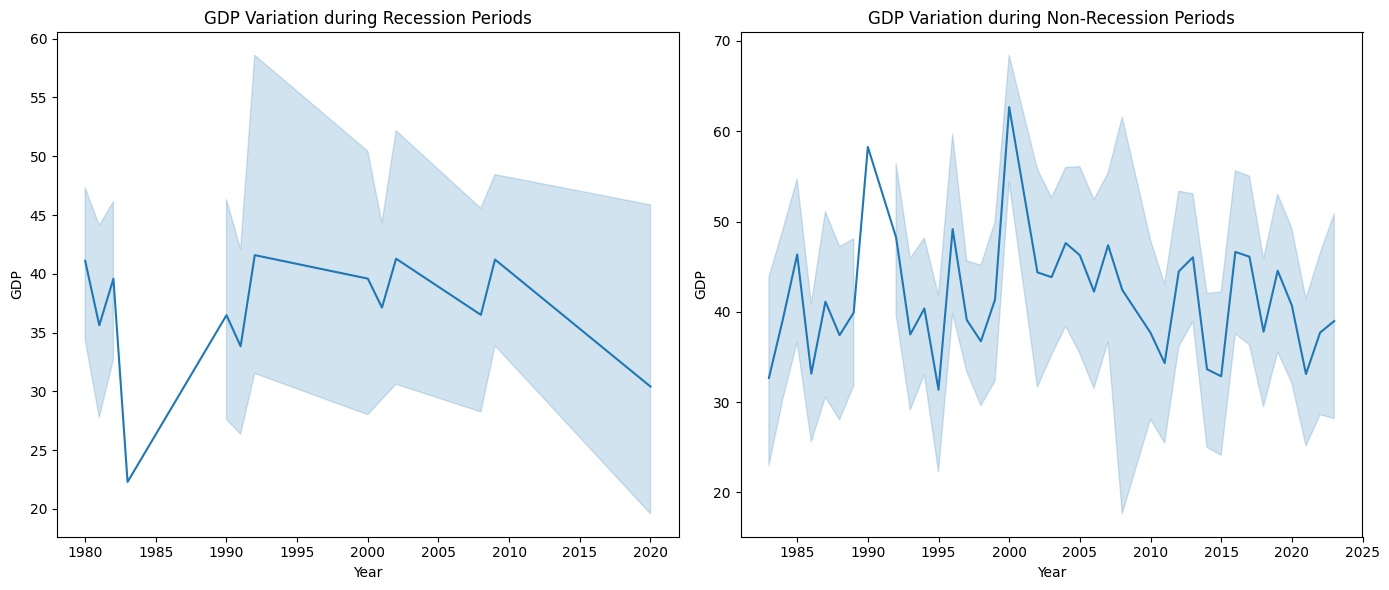

In [5]:
rec_data = df[df['Recession'] == 1]
non_rec_data = df[df['Recession'] == 0]

fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

sns.lineplot(x='Year', y='GDP', data=rec_data, ax=ax0)
ax0.set_title('GDP Variation during Recession Periods')
ax0.set_xlabel('Year')
ax0.set_ylabel('GDP')

sns.lineplot(x='Year', y='GDP', data=non_rec_data, ax=ax1)
ax1.set_title('GDP Variation during Non-Recession Periods')
ax1.set_xlabel('Year')
ax1.set_ylabel('GDP')

plt.tight_layout()
plt.show()

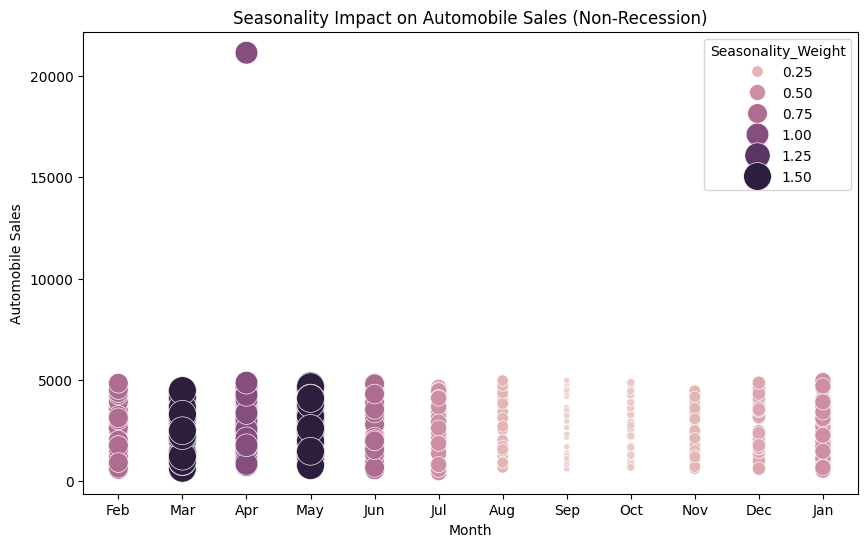

In [6]:
non_rec = df[df['Recession'] == 0]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=non_rec,
    x='Month',
    y='Automobile_Sales',
    size='Seasonality_Weight',
    hue='Seasonality_Weight',
    sizes=(20, 400),
    legend=True
)
plt.title('Seasonality Impact on Automobile Sales (Non-Recession)')
plt.xlabel('Month')
plt.ylabel('Automobile Sales')
plt.show()

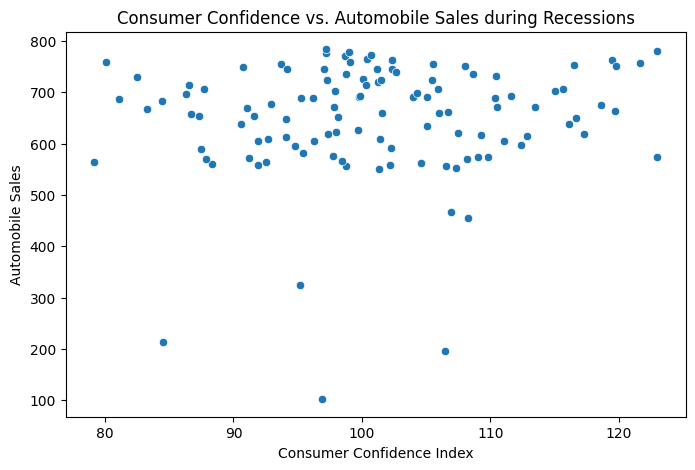

In [7]:
rec_data = df[df['Recession'] == 1]

plt.figure(figsize=(8, 5))
sns.scatterplot(x='Consumer_Confidence', y='Automobile_Sales', data=rec_data)
plt.title('Consumer Confidence vs. Automobile Sales during Recessions')
plt.xlabel('Consumer Confidence Index')
plt.ylabel('Automobile Sales')
plt.show()

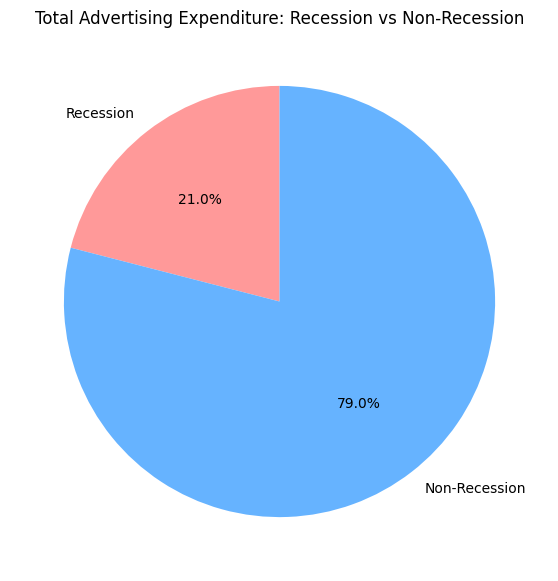

In [8]:
rec_exp = df[df['Recession'] == 1]['Advertising_Expenditure'].sum()
non_rec_exp = df[df['Recession'] == 0]['Advertising_Expenditure'].sum()

plt.figure(figsize=(7, 7))
plt.pie(
    [rec_exp, non_rec_exp],
    labels=['Recession', 'Non-Recession'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#ff9999', '#66b3ff']
)
plt.title('Total Advertising Expenditure: Recession vs Non-Recession')
plt.show()

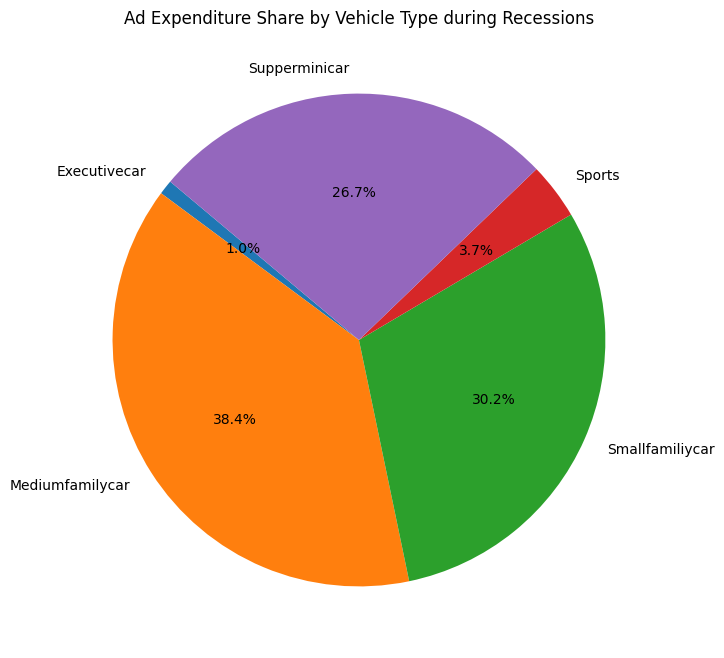

In [9]:
rec_data = df[df['Recession'] == 1]
ad_by_type = rec_data.groupby('Vehicle_Type')['Advertising_Expenditure'].sum()

plt.figure(figsize=(8, 8))
plt.pie(
    ad_by_type,
    labels=ad_by_type.index,
    autopct='%1.1f%%',
    startangle=140
)
plt.title('Ad Expenditure Share by Vehicle Type during Recessions')
plt.show()